In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier





In [2]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# ================================
# 🔹 Step 4: แยก X, y และแบ่งชุด Train/Test
# ================================
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 🔹 Step 5: สร้างและเทรนโมเดล Random Forest
# ================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ================================
# 🔹 Step 6: คำนวณ Feature Importances
# ================================
rf_feature_importances = rf.feature_importances_
feature_names = np.array(X.columns)
sorted_idx = rf_feature_importances.argsort()

# ================================
# 🔹 Step 7: แสดงกราฟ Feature Importances
# ================================
plt.figure(figsize=(8, 6))
y_ticks = np.arange(0, len(feature_names))
plt.barh(y_ticks, rf_feature_importances[sorted_idx], color='skyblue', edgecolor='black')
plt.yticks(y_ticks, feature_names[sorted_idx])
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

In [ ]:
cols = ["Complain", "Age", "NumOfProducts", "IsActiveMember", "Balance", "CreditScore", "Exited"]
df = df[cols]
df


,Complain,Age,NumOfProducts,IsActiveMember,Balance,CreditScore,Exited
0,1,42,1,1,0.00,619,1
1,1,41,1,1,83807.86,608,0
2,1,42,3,0,159660.80,502,1
3,0,39,2,0,0.00,699,0
4,0,43,1,1,125510.82,850,0
...,...,...,...,...,...,...,...
9995,0,39,2,0,0.00,771,0
9996,0,35,1,1,57369.61,516,0
9997,1,36,1,1,0.00,709,1
9998,1,42,2,0,75075.31,772,1


In [ ]:
df.isnull().sum()
df

,Complain,Age,NumOfProducts,IsActiveMember,Balance,CreditScore,Exited
0,1,42,1,1,0.00,619,1
1,1,41,1,1,83807.86,608,0
2,1,42,3,0,159660.80,502,1
3,0,39,2,0,0.00,699,0
4,0,43,1,1,125510.82,850,0
...,...,...,...,...,...,...,...
9995,0,39,2,0,0.00,771,0
9996,0,35,1,1,57369.61,516,0
9997,1,36,1,1,0.00,709,1
9998,1,42,2,0,75075.31,772,1


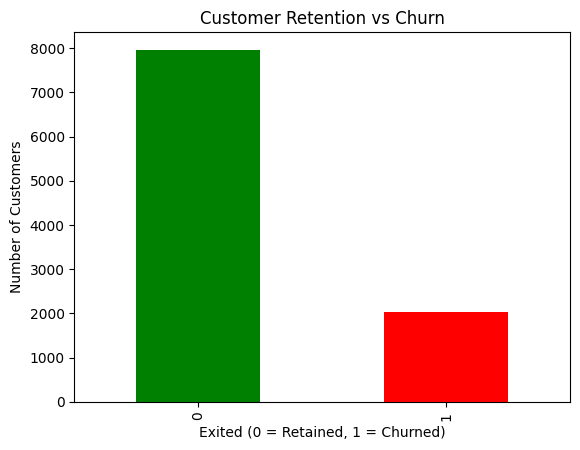

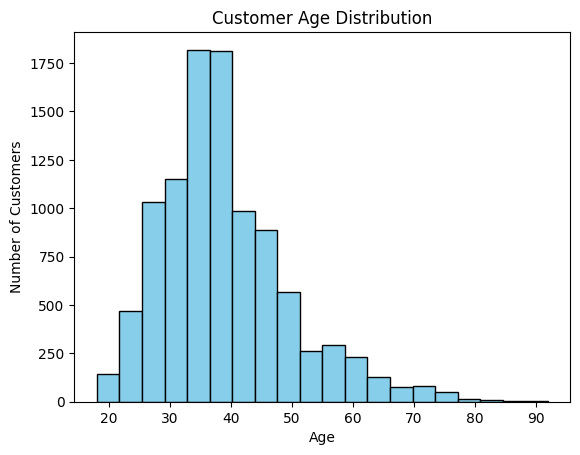

In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'
df['Exited'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Customer Retention vs Churn')
plt.xlabel('Exited (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()


plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
df.head()

,Complain,Age,NumOfProducts,IsActiveMember,Balance,CreditScore,Exited
0,1,42,1,1,0.00,619,1
1,1,41,1,1,83807.86,608,0
2,1,42,3,0,159660.80,502,1
3,0,39,2,0,0.00,699,0
4,0,43,1,1,125510.82,850,0


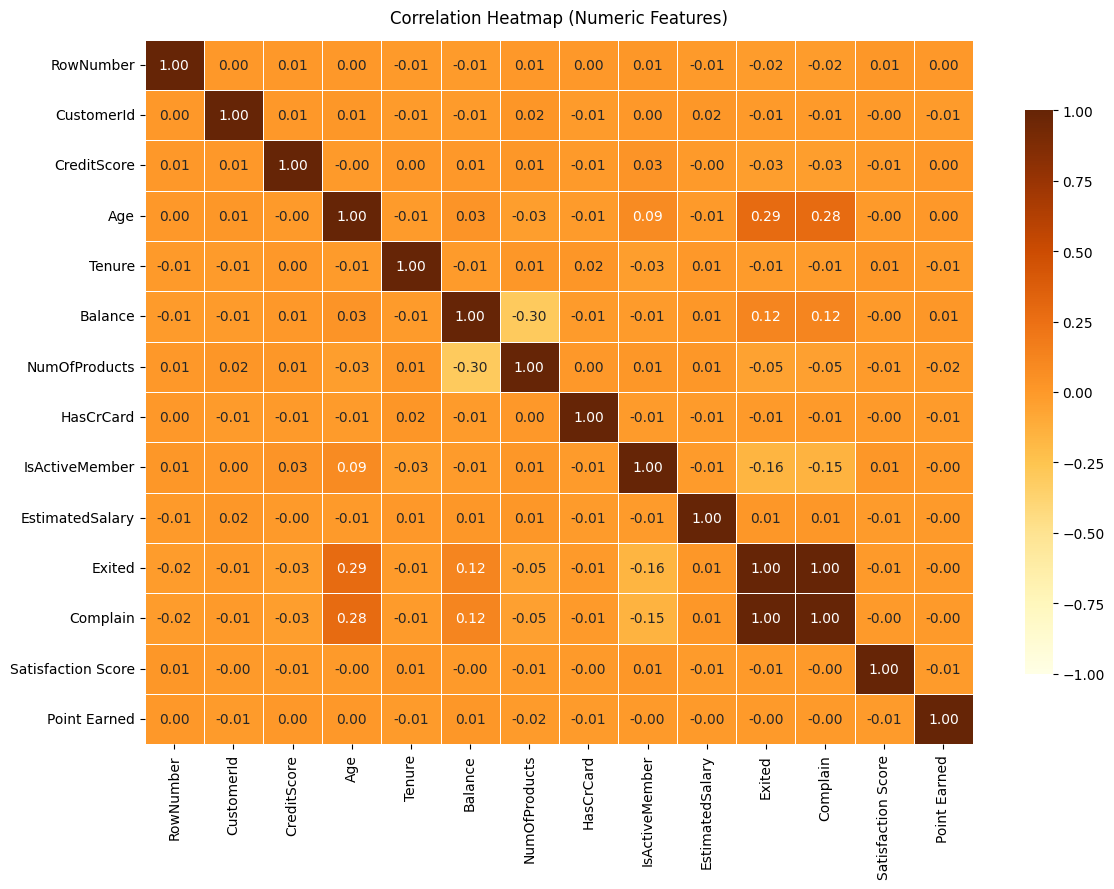

In [3]:
df = pd.read_csv("Customer-Churn-Records.csv")
num_df = df.select_dtypes(include=[np.number])  # ตัด Geography, Gender, Surname ฯลฯ ออก

# 1) คำนวณค่าสหสัมพันธ์
corr = num_df.corr(method='pearson')


# 2) วาด heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr, 
    cmap='YlOrBr',       # โทนเหลือง-ส้ม-น้ำตาลเหมือนตัวอย่าง
    annot=True,          # ใส่ตัวเลขในช่อง
    fmt=".2f",           # แสดงทศนิยม 2 ตำแหน่ง
    vmin=-1, vmax=1,     # สเกลเต็มช่วง -1..1
    linewidths=.5,       # เส้นแบ่งช่อง
    cbar_kws={'shrink': .8}
)
plt.title("Correlation Heatmap (Numeric Features)", pad=12)
plt.tight_layout()
plt.show()